# Agentic RAG

### Workflow

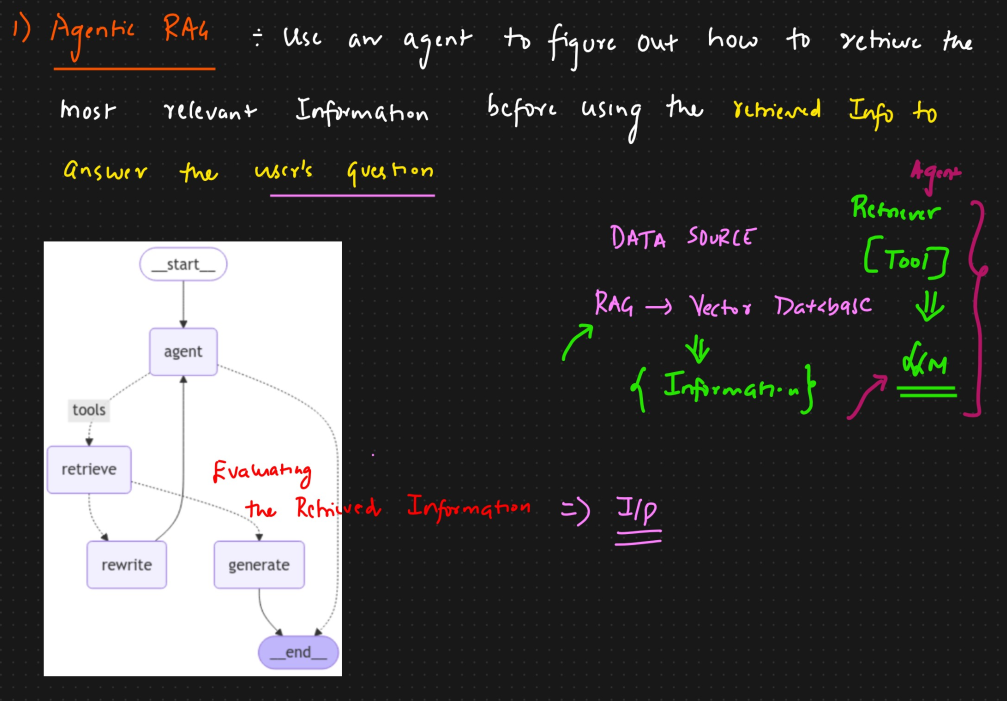


In [53]:
import os
from dotenv import load_dotenv
load_dotenv()  # Loading all the environment variables

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")

In [54]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name = "all-MiniLM-L6-v2")
embeddings

HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [55]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter

urls = [
      "https://docs.langchain.com/oss/python/langgraph/overview",
      "https://docs.langchain.com/oss/python/langgraph/workflows-agents#workflows-and-agents",
      "https://docs.langchain.com/oss/python/deepagents/overview"
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
      chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)



# Add all these texts to vectordb
vectorstore = FAISS.from_documents(
      documents = doc_splits,
      embedding = embeddings
)


retriever = vectorstore.as_retriever()

In [56]:
retriever.invoke("What is a deep agent ?")

[Document(id='ab5e688d-9dd3-4d34-b117-a74f11a303df', metadata={'source': 'https://docs.langchain.com/oss/python/deepagents/overview', 'title': 'Deep Agents overview - Docs by LangChain', 'description': 'Build agents that can plan, use subagents, and leverage file systems for complex tasks', 'language': 'en'}, page_content='Deep Agents overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationDeep Agents overviewOverviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedQuickstartCustomizationComparison with Claude Agent SDKChangelogDeploymentManaged Deep AgentsBETAGoing to productionCore capabilitiesModelsToolsContext engineeringBackendsSubagentsAsync subagentsHuman-in-the-loopPermissionsMemorySkillsSandboxesInterpreter

In [57]:
from langchain.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
      retriever,
      "retriever_vector_db_blog",
      "Search and return information about deep agents"
)

In [58]:
retriever_tool

Tool(name='retriever_vector_db_blog', description='Search and return information about deep agents', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x77d58711bb00>, retriever=VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x77d5252d1f90>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), document_separator='\n\n', response_format='content'), coroutine=functools.partial(<function _aget_relevant_documents at 0x77d58711b740>, retriever=VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x77d5252d1f90>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), d

In [59]:
tools = [retriever_tool]

In [60]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
      # The add_messages function define how an update should be processed
      # Default is to replace. add_messages says "append"
      messages: Annotated[Sequence[BaseMessage], add_messages]

In [61]:
from langchain_groq import ChatGroq

def agent(state):
      """
      Invokes the agent model to generate a response based on the current state. Given
      the question, it will decide to retrieve using the retriever tool, or simply end.

      Args: state (messages): The current state

      Returns: dict: The updated state with the agent response appended to messages
      """

      print("--- CALL AGENT ---")
      messages = state["messages"]
      model = ChatGroq(model="llama-3.3-70b-versatile")
      model = model.bind_tools(tools)

      response = model.invoke(messages)

      # We return list because it will be added to existing list
      return {"messages": [response]}

In [62]:
from typing import Annotated, Sequence, Literal
from typing_extensions import TypedDict

from langchain import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq

from pydantic import BaseModel, Field

In [63]:
# Edges
def grade_document(state) -> Literal["generate", "rewrite"]:
      """
      Determines whether the retrieved docukents/are relevant to the question.

      Args: 
            state (messages): The current state

      Returns: 
            str: A decision for whether the documents are relevant or not
      """

      print("--- CHECK RELEVANCE ---")

      # Data Model
      class grade(BaseModel):
            "Binary Score for Relevance Check"
            
            binary_score: str = Field(description="Relevance score 'yes' or 'no'")

      # LLM
      model = ChatGroq(model="llama-3.3-70b-versatile")

      # LLM with Tools and validation
      llm_with_tools = model.with_structured_output(grade)

      # prompt
      prompt = PromptTemplate(
            template = """ You are a grader accessing relevance of a retrieved document to a user question. \n
            Here is the retrieved document: \n\n {context} \n\n
            Here is the user question: {question} \n
            If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
            Give a binary score 'yes' or 'no' score to indicate whether document is relevant to the question.
            """,
            input_variable = ["context", "question"],
      )

      # Chain
      chain = prompt | llm_with_tools

      messages = state["messages"]
      last_message = messages[-1]

      question = messages[0].content
      docs = last_message.content

      scored_result = chain.invoke({"question": question, "context": docs})

      score  = scored_result.binary_score

      if score == "yes":
            print("--- DECISION: DOCS RELEVANT ---")
            return "generate"

      else:
            print("--- DECISION: DOCS NOT RELEVANT ---")
            print(score)
            return "rewrite"

In [64]:
def generate(state):
      """
      Generate answer 

      Args: 
      state (messages): The current state

      Returns:
      dict: The updated message
      """

      print("--- GENERATE ---")

      messages = state["messages"]
      question = messages[0].content
      last_message = messages[-1]

      docs = last_message.content

      # Prompt
      prompt = hub.pull("rlm/rag-prompt")

      #LLM
      llm = ChatGroq(model="llama-3.3-70b-versatile")


      # Post-processing
      def format_docs(docs):
            return "\n\n".join(doc.page_content for doc in docs)

      # Chain
      rag_chain = prompt | llm | StrOutputParser()

      # Run
      response = rag_chain.invoke({"context": docs, "question": question})
      return {"messages": [response]}

In [65]:
print("*" * 20 + "Prompt[rlm/rag-prompt]" + "*" * 20 )
prompt = hub.pull("rlm/rag-prompt").pretty_print()

********************Prompt[rlm/rag-prompt]********************
================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [66]:
def rewrite(state):
      """
      Transform the query to produce a better question.
      Args: state (messages): The current stat
      Returns: dict:
      """

      print("--- TRANSFORM QUERY ---")
      messages = state["messages"]
      question = messages[0].content

      msg = [
            HumanMessage(
                  content=f""" \n
                        Look at the input and try to reason about the underlying semantic intent / meaning. \n 
                        Here is the initial question:
                        \n <------- \n 
                        {question} 
                        \n ------- \n
                        Formulate an improved question: """,
            )
      ]


      # Grader
      model = ChatGroq(model="llama-3.3-70b-versatile")
      response = model.invoke(msg)

      return {"messages": [response]}


In [67]:
from langgraph.graph import START, StateGraph, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a graph
workflow = StateGraph(AgentState)

# Define the node we will cycle between
workflow.add_node("agent",agent) # agent
retrieve = ToolNode([retriever_tool])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # re-writing the question
workflow.add_node(
      "generate", generate
) # Generating a response after we know that documents are relevant

# Call Agent Node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve or not
workflow.add_conditional_edges(
      "agent",
      # Access Agent Decision
      tools_condition,
      {
            # Translate the condition outputs to node in our graph
            "tools": "retrieve",
            END : END,
      },
)

# Edges taken after the action node is called
workflow.add_conditional_edges(
      "retrieve",
      # Access Agent Decision
      grade_document,
)

workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()


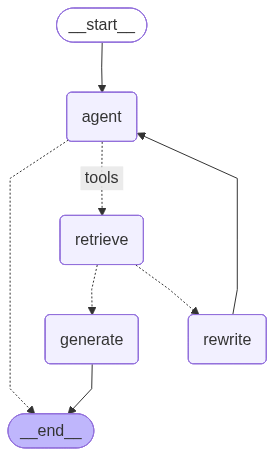

In [68]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [69]:
graph.invoke({"messages":"What is Deep Agent ?"})

--- CALL AGENT ---


--- CHECK RELEVANCE ---
--- DECISION: DOCS RELEVANT ---
--- GENERATE ---


{'messages': [HumanMessage(content='What is Deep Agent ?', additional_kwargs={}, response_metadata={}, id='01a18cfd-87de-4491-9dae-4710f0d6ca36'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '1ppsghh53', 'function': {'arguments': '{"query":"Deep Agent definition"}', 'name': 'retriever_vector_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 237, 'total_tokens': 257, 'completion_time': 0.036323848, 'completion_tokens_details': None, 'prompt_time': 0.023154834, 'prompt_tokens_details': None, 'queue_time': 0.162050219, 'total_time': 0.059478682}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--019efd6d-7e09-7a00-b5ee-e60d79f52b34-0', tool_calls=[{'name': 'retriever_vector_db_blog', 'args': {'query': 'Deep Agent definition'}, 'id': '1ppsghh53', 'type': 'tool_call'}], usage_metadata={'input_t

In [70]:
inputs = {
      "messages": "What is Deep Agent ?"
}

for output in graph.stream(inputs):
      print(output)

--- CALL AGENT ---
{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'w1j7xkfqn', 'function': {'arguments': '{"query":"Deep Agent"}', 'name': 'retriever_vector_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 237, 'total_tokens': 256, 'completion_time': 0.028603961, 'completion_tokens_details': None, 'prompt_time': 0.013142649, 'prompt_tokens_details': None, 'queue_time': 0.161708985, 'total_time': 0.04174661}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--019efd6d-8460-7b90-b9a6-3682daa25c84-0', tool_calls=[{'name': 'retriever_vector_db_blog', 'args': {'query': 'Deep Agent'}, 'id': 'w1j7xkfqn', 'type': 'tool_call'}], usage_metadata={'input_tokens': 237, 'output_tokens': 19, 'total_tokens': 256})]}}
--- CHECK RELEVANCE ---
--- DECISION: DOCS RELEVANT ---
{'retrieve': {